# HybridStrategy SWAPNET — flat dispatch via `switch`

The existing `HybridStrategy` in [dynamic_experiment/qpa_engine.py](dynamic_experiment/qpa_engine.py) dispatches on Schur outcomes by recursively building a chain of `with qc.if_test(bit==v):` contexts (the `apply_conditions` helper). For each trial with `m` parallel pairs, this nests `m` deep per outcome. With `T > 1` the recursion stacks another control-flow context per trial.

Two equivalent flatter formulations are supported by Qiskit's control-flow API:

1. **`if_test((register, int))`** — compare the entire `ClassicalRegister` to an integer in one shot. The per-outcome branch becomes a single context manager regardless of `m`.
2. **`switch_case` over the register** — one switch dispatches all outcomes of a trial in one block.

Below I show the original nested version, then a `switch`-based variant, both at `N=3, k=2, T ∈ {1,2,3}`.

> **Note on N=3.** With `N=3` each trial has `(N-1)/2 = 1` pair, so `apply_conditions` is already a chain of length 1 — there is no per-trial nesting to remove. The trial-to-trial nesting (T-deep) is unavoidable in dynamic circuits because each layer needs the previous measurement. The win at N=3 is therefore **API cleanliness**, not depth reduction. The nested-chain reduction shows up at N≥5; a small comparison is at the bottom.

## Imports & helpers

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from itertools import product
from IPython.display import display
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

from dynamic_experiment.qpa_engine import (
    HybridStrategy,
    apply_schur_test,
    apply_cyclic_rotation,
)

N_REGISTERS = 3
K = 2
T_VALUES = [1, 2, 3]
print(f'N={N_REGISTERS}, k={K}, T∈{T_VALUES}')

N=3, k=2, T∈[1, 2, 3]


## 1. Original `HybridStrategy` (nested `if_test` chain)


=== Original HybridStrategy — T=1 ===
  qubits=8, clbits=4, depth=7
  ops: {'measure': 3, 'h': 2, 'cswap': 2, 'if_else': 2, 'reset': 1}


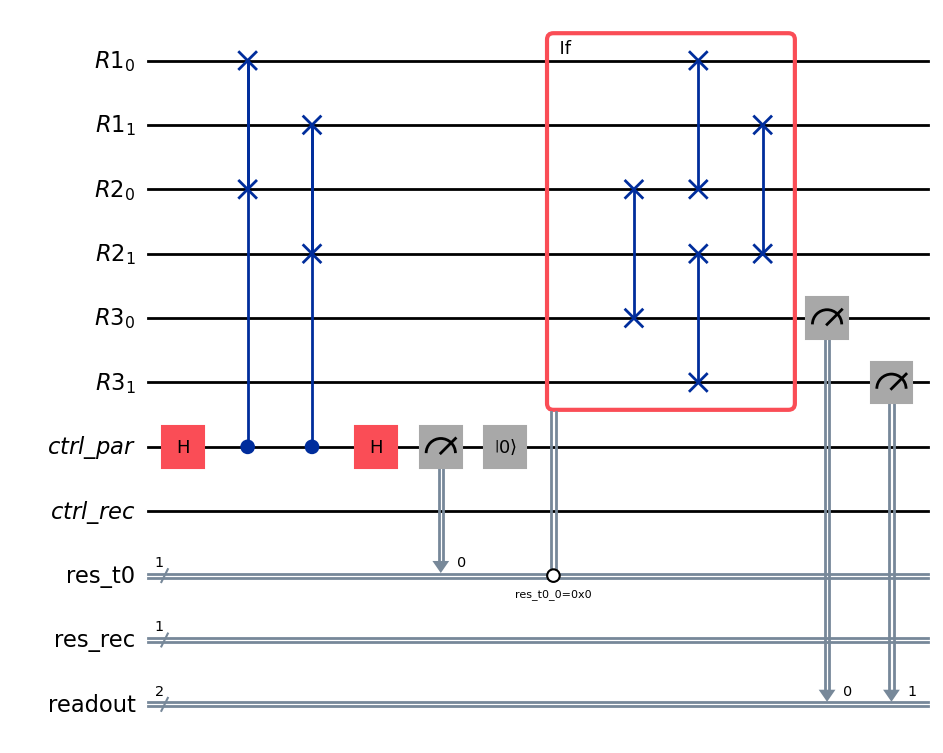


=== Original HybridStrategy — T=2 ===
  qubits=8, clbits=6, depth=8
  ops: {'measure': 3, 'h': 2, 'cswap': 2, 'if_else': 2, 'reset': 1}


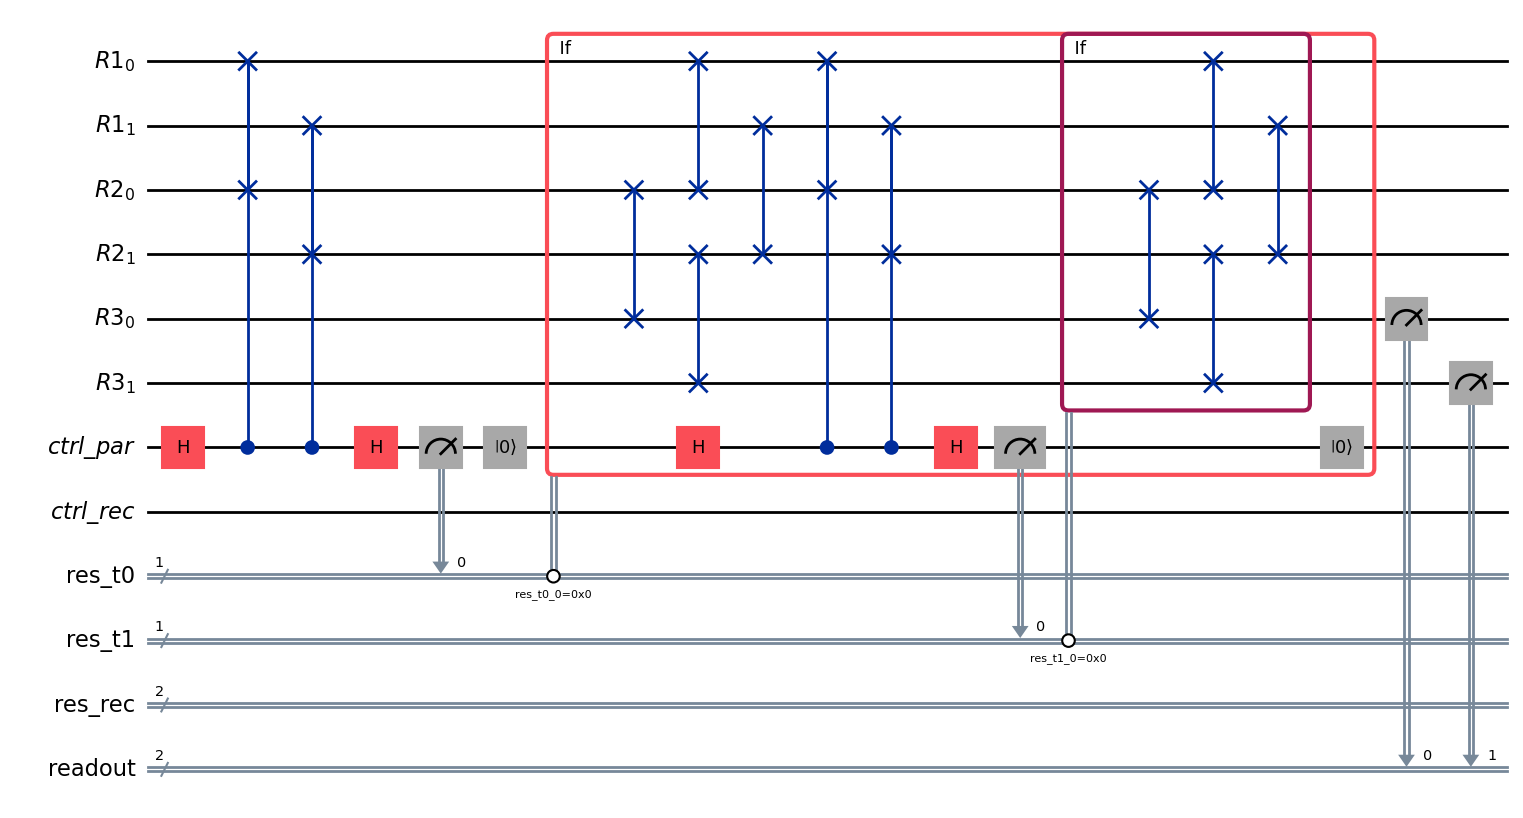


=== Original HybridStrategy — T=3 ===
  qubits=8, clbits=8, depth=8
  ops: {'measure': 3, 'h': 2, 'cswap': 2, 'if_else': 2, 'reset': 1}


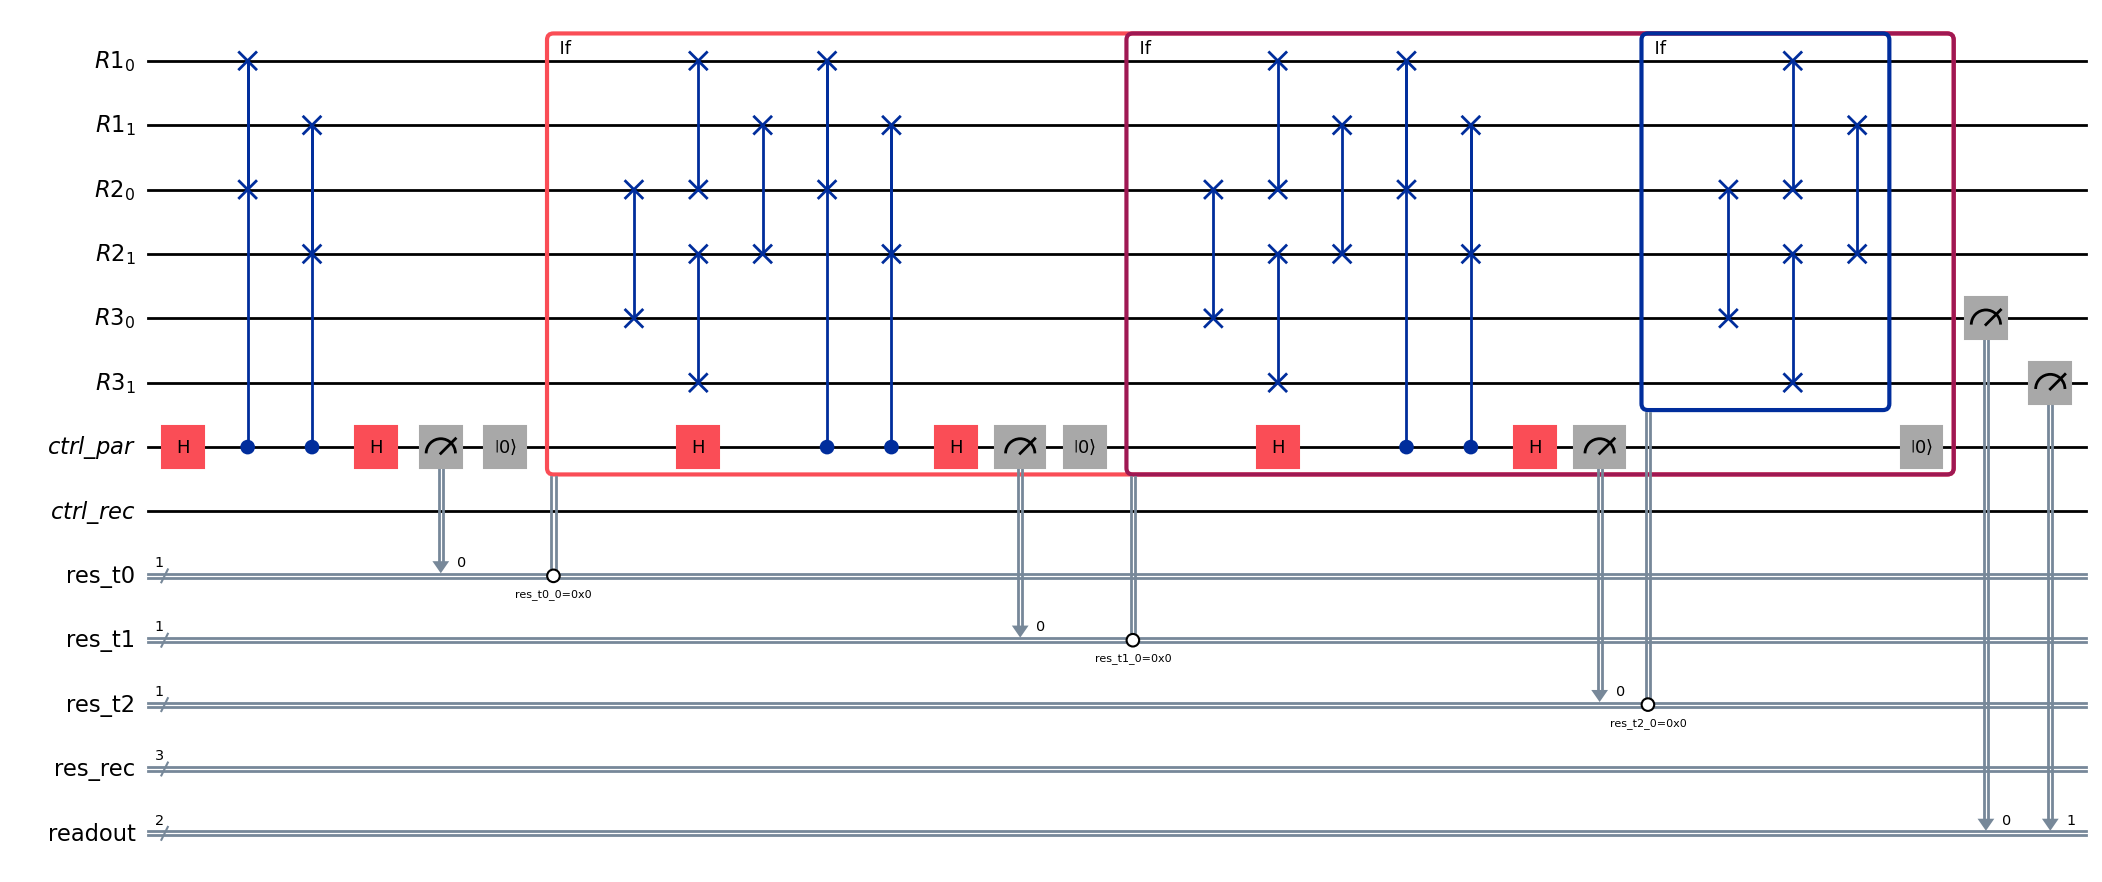

In [2]:
original_circuits = {}
for T in T_VALUES:
    strat = HybridStrategy(k=K, n_trials=T, n_registers=N_REGISTERS)
    qc = strat.build_circuit(epsilon=0.0)
    original_circuits[T] = qc
    print(f'\n=== Original HybridStrategy — T={T} ===')
    print(f'  qubits={qc.num_qubits}, clbits={qc.num_clbits}, depth={qc.depth()}')
    print(f'  ops: {dict(qc.count_ops())}')
    display(qc.draw(output="mpl", fold=120))

## 2. Flat variant: `switch` over the trial's classical register

Same protocol, but each trial dispatches via a single `qc.switch(current_cr)` block with one `case(outcome_int)` per outcome — no `apply_conditions` chain. The recursive call into the next trial happens inside the matching `case` body, exactly as before.


=== HybridStrategySwitch — T=1 ===
  qubits=8, clbits=4, depth=7
  ops: {'measure': 3, 'h': 2, 'cswap': 2, 'reset': 1, 'switch_case': 1}


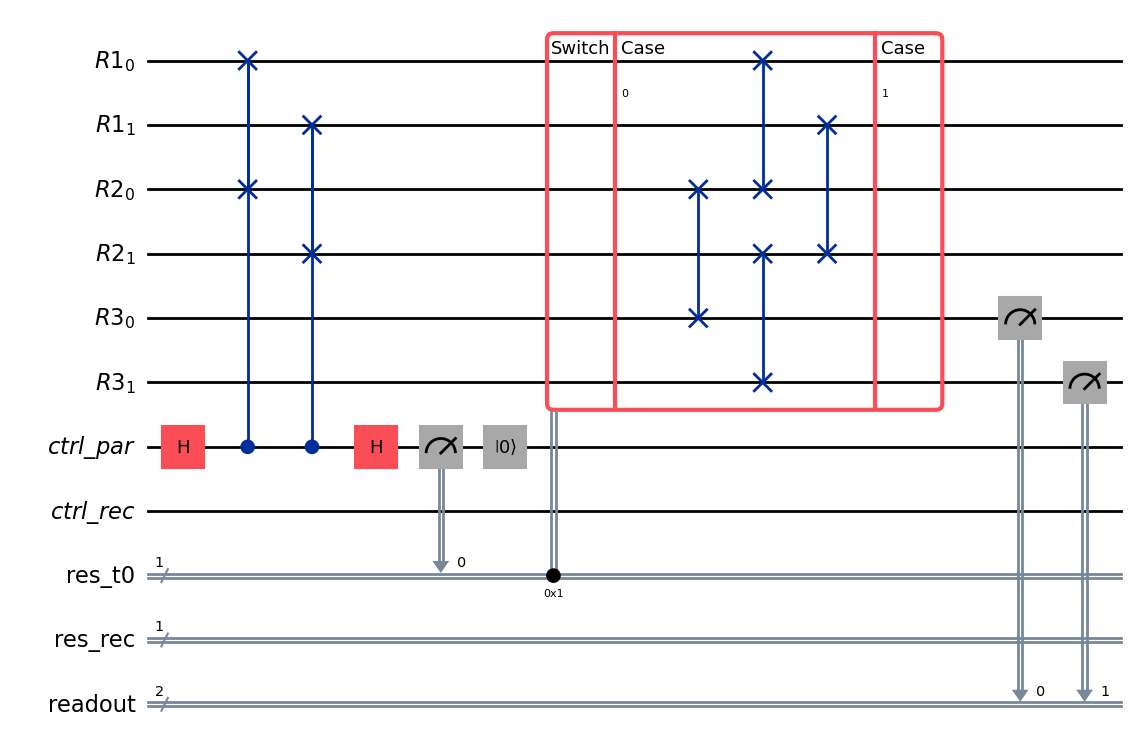


=== HybridStrategySwitch — T=2 ===
  qubits=8, clbits=6, depth=8
  ops: {'measure': 3, 'h': 2, 'cswap': 2, 'reset': 1, 'switch_case': 1}


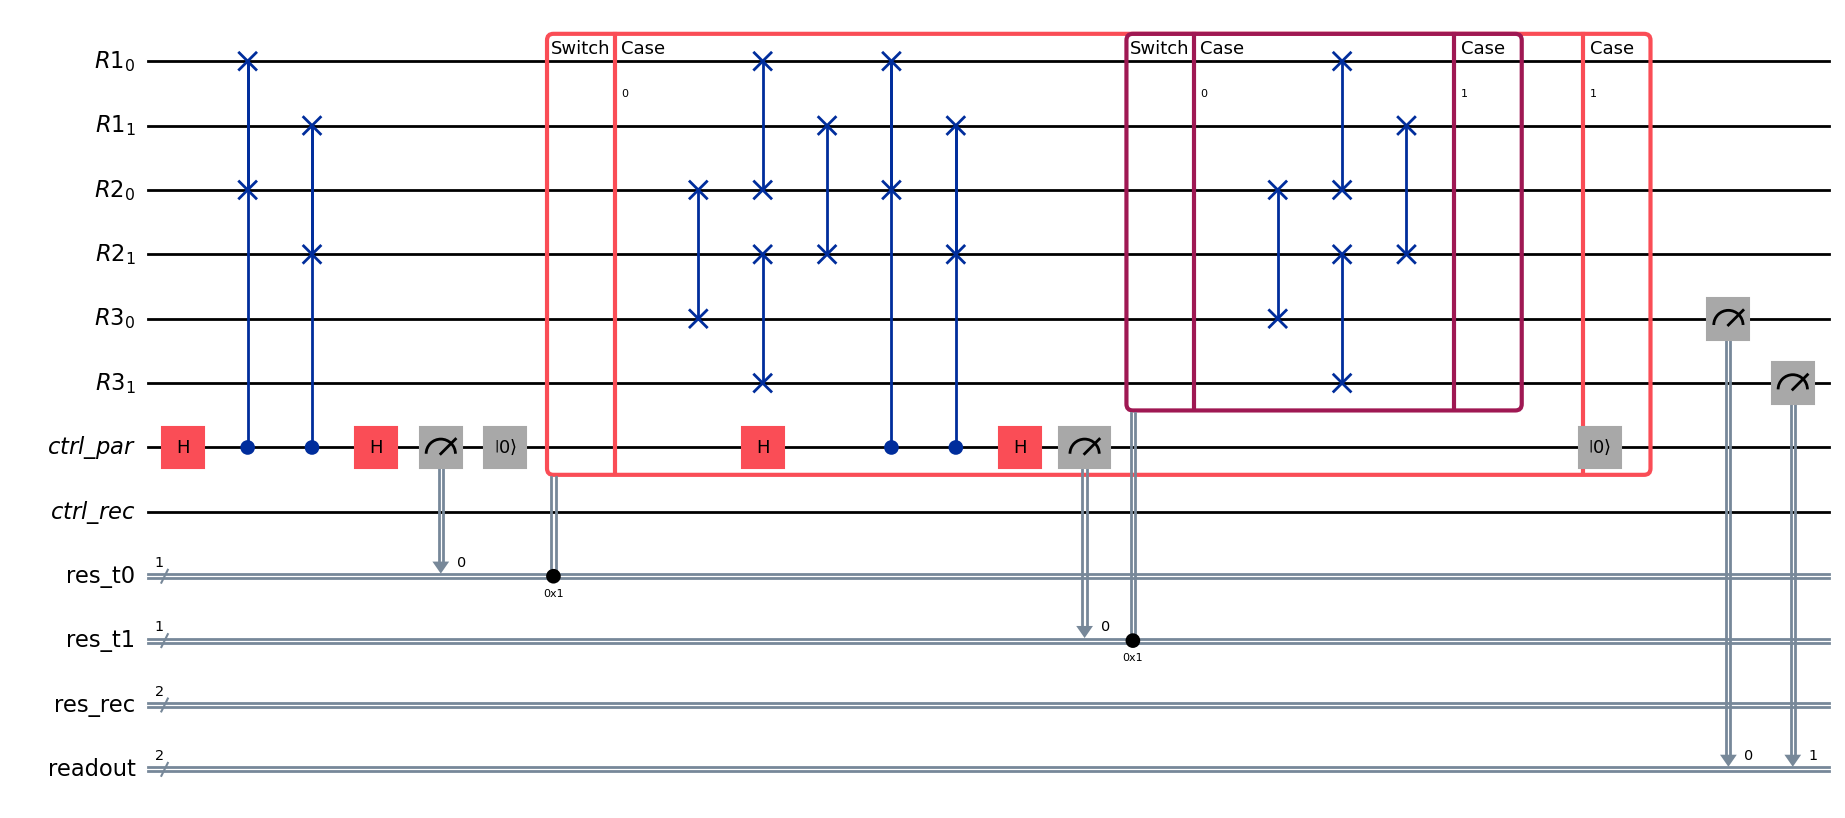


=== HybridStrategySwitch — T=3 ===
  qubits=8, clbits=8, depth=8
  ops: {'measure': 3, 'h': 2, 'cswap': 2, 'reset': 1, 'switch_case': 1}


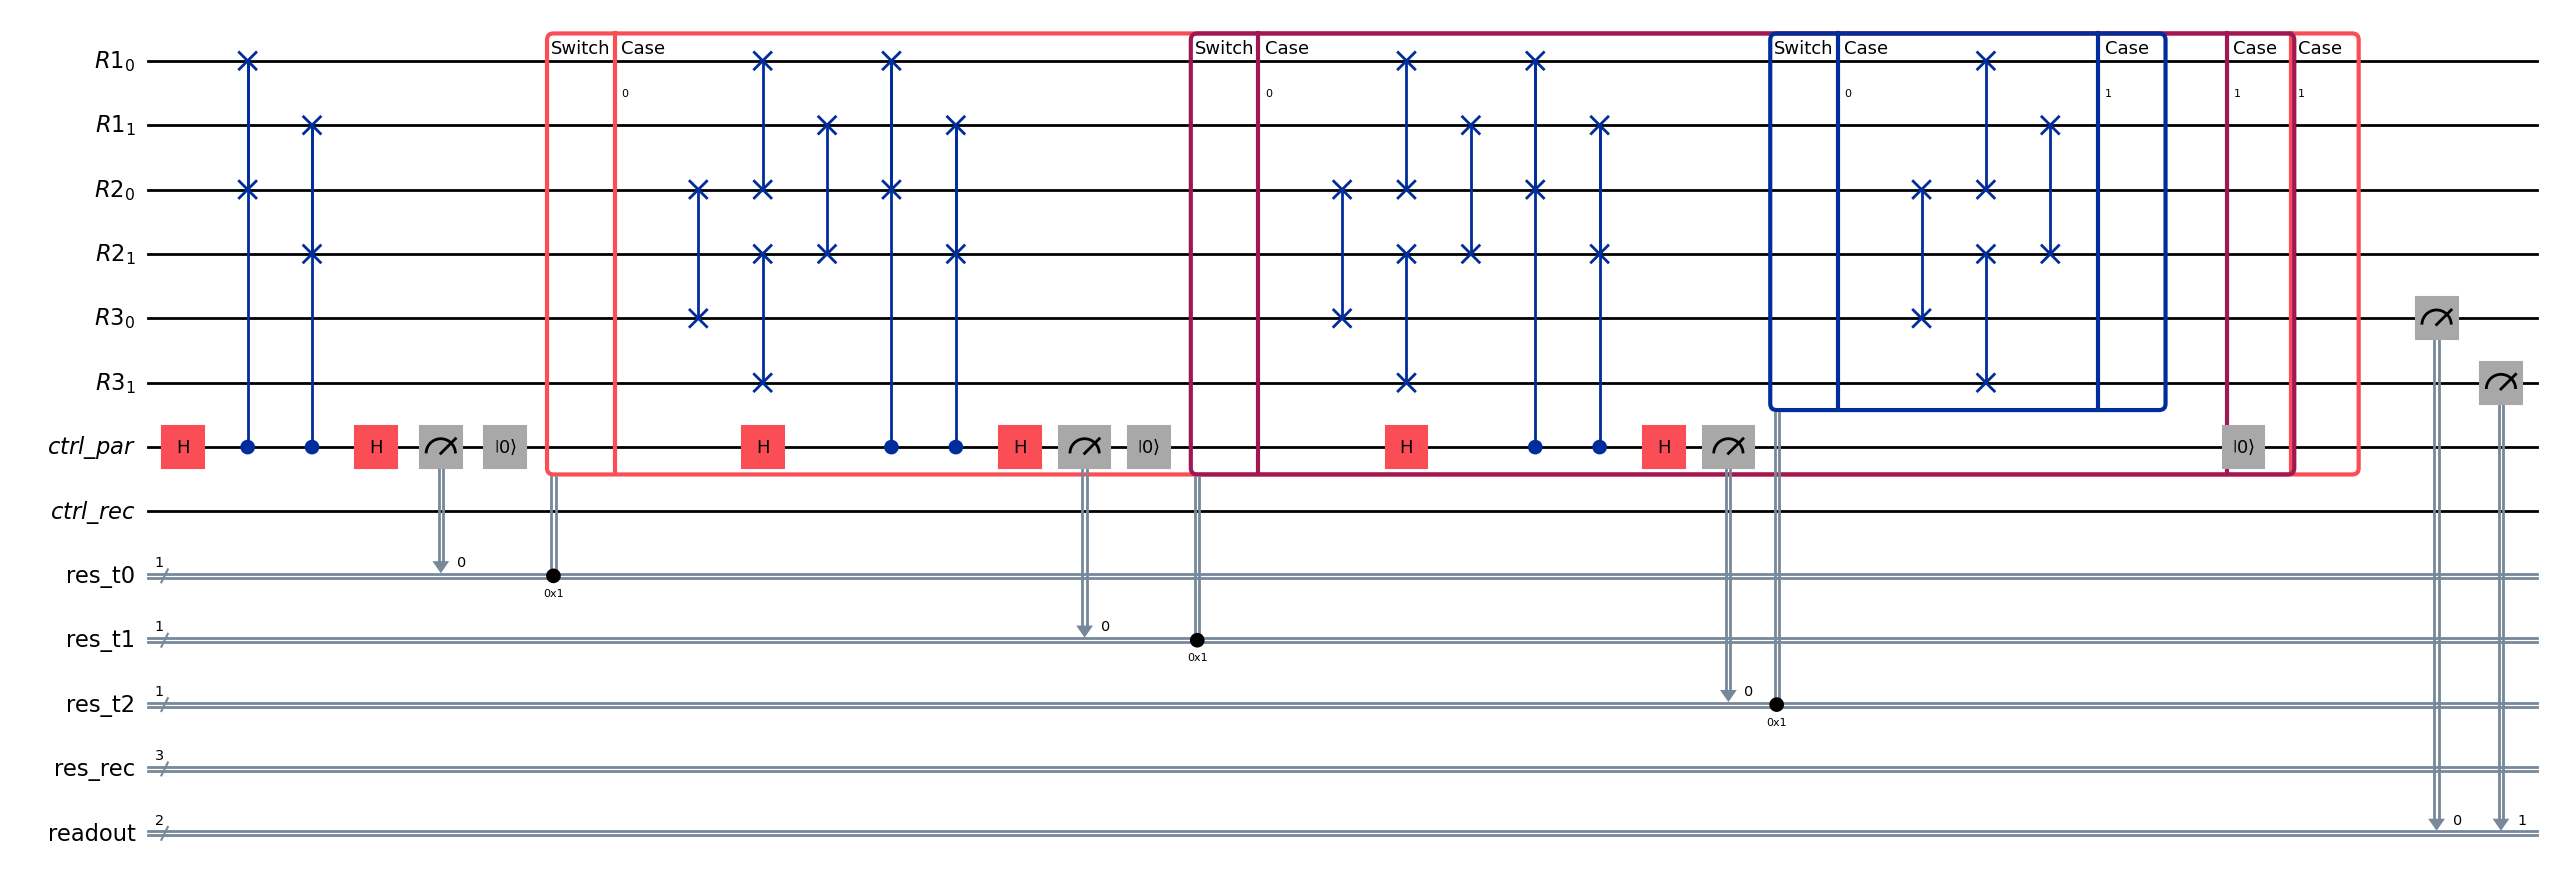

In [3]:
class HybridStrategySwitch:
    """HybridStrategy where outcome dispatch uses qc.switch instead of nested if_test."""

    def __init__(self, k, n_trials, n_registers):
        self.k = k
        self.n_trials = n_trials
        self.n_registers = n_registers

    def build_circuit(self, epsilon=0.0):
        qr_data = [QuantumRegister(self.k, f'R{i+1}') for i in range(self.n_registers)]
        max_par = (self.n_registers - 1) // 2
        qr_ctrl_par = QuantumRegister(max_par, 'ctrl_par')
        qr_ctrl_rec = QuantumRegister(1, 'ctrl_rec')
        cr_pool = [ClassicalRegister(max_par, f'res_t{t}') for t in range(self.n_trials)]
        cr_rec = ClassicalRegister(self.n_trials, 'res_rec')
        cr_final = ClassicalRegister(self.k, 'readout')

        qc = QuantumCircuit(*qr_data, qr_ctrl_par, qr_ctrl_rec, *cr_pool, cr_rec, cr_final)

        # epsilon=0.0 here — global noise is omitted to keep the demo circuit clean.

        initial_reserve = qr_data[-1]
        initial_pairs = [(qr_data[i], qr_data[i + 1])
                         for i in range(0, self.n_registers - 1, 2)]

        self._build_layer(qc, initial_pairs, initial_reserve,
                          qr_ctrl_par, cr_pool, current_trial=0)

        qc.measure(initial_reserve, cr_final)
        return qc

    def _build_layer(self, qc, current_pairs, reserve_reg,
                     qr_par, cr_pool, current_trial):
        if current_trial >= self.n_trials:
            return

        num_pairs = len(current_pairs)
        current_cr = cr_pool[current_trial]

        # 1. Parallel Schur tests, measure into current_cr
        for i in range(num_pairs):
            apply_schur_test(qc, qr_par[i],
                             current_pairs[i][0], current_pairs[i][1],
                             self.k, include_measure=True, res_bit=current_cr[i])

        # 2. Single switch over the trial's classical register dispatches all outcomes
        with qc.switch(current_cr) as case:
            for outcome in product([0, 1], repeat=num_pairs):
                outcome_int = sum(v << i for i, v in enumerate(outcome))
                with case(outcome_int):
                    if all(v == 0 for v in outcome):
                        all_regs = [r for p in current_pairs for r in p] + [reserve_reg]
                        apply_cyclic_rotation(qc, all_regs, self.k)
                        self._build_layer(qc, current_pairs, reserve_reg,
                                          qr_par, cr_pool, current_trial + 1)
                    else:
                        surviving = [current_pairs[i]
                                     for i, v in enumerate(outcome) if v == 0]
                        if surviving:
                            active = [r for p in surviving for r in p] + [reserve_reg]
                            apply_cyclic_rotation(qc, active, self.k)
                            self._build_layer(qc, surviving, reserve_reg,
                                              qr_par, cr_pool, current_trial + 1)


switch_circuits = {}
for T in T_VALUES:
    strat = HybridStrategySwitch(k=K, n_trials=T, n_registers=N_REGISTERS)
    qc = strat.build_circuit(epsilon=0.0)
    switch_circuits[T] = qc
    print(f'\n=== HybridStrategySwitch — T={T} ===')
    print(f'  qubits={qc.num_qubits}, clbits={qc.num_clbits}, depth={qc.depth()}')
    print(f'  ops: {dict(qc.count_ops())}')
    display(qc.draw(output="mpl", fold=120))

## 3. Side-by-side summary

In [4]:
print(f'{"T":>3} | {"orig depth":>10} {"orig ops":>10}  ||  {"switch depth":>12} {"switch ops":>11}')
print('-' * 70)
for T in T_VALUES:
    o = original_circuits[T]
    s = switch_circuits[T]
    o_ops = sum(o.count_ops().values())
    s_ops = sum(s.count_ops().values())
    print(f'{T:>3} | {o.depth():>10} {o_ops:>10}  ||  {s.depth():>12} {s_ops:>11}')

  T | orig depth   orig ops  ||  switch depth  switch ops
----------------------------------------------------------------------
  1 |          7         10  ||             7           9
  2 |          8         10  ||             8           9
  3 |          8         10  ||             8           9


## 4. (Optional) Where the win is bigger — N=5

At `N=5` each trial has 2 parallel pairs, so the original `apply_conditions` builds a 2-deep `if_test` chain per outcome × 4 outcomes per trial. `switch` collapses this to one block per trial.

In [5]:
for T in [1, 2]:
    o = HybridStrategy(k=K, n_trials=T, n_registers=5).build_circuit(epsilon=0.0)
    s = HybridStrategySwitch(k=K, n_trials=T, n_registers=5).build_circuit(epsilon=0.0)
    print(f'N=5, T={T}: original depth={o.depth()} ops={sum(o.count_ops().values())}  '
          f'|  switch depth={s.depth()} ops={sum(s.count_ops().values())}')

N=5, T=1: original depth=9 ops=18  |  switch depth=7 ops=15
N=5, T=2: original depth=10 ops=18  |  switch depth=8 ops=15
